In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import re
import json
import math
import glob
import torch
import base64
from io import BytesIO
import matplotlib.image as mpimg

from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from datetime import datetime, timedelta
from PIL import Image

from prompt import time_series_to_image
from utils import view_base64_image, display_messages, collect_results, compute_metrics, interval_to_vector, plot_series_and_predictions, plot_series_and_predictions_with_timestamp
from data.synthetic import SyntheticDataset

from neurips_our.AnoAgent import AnoAgent

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
def average_dict_values(dict_list):
    sums = {}
    counts = {}

    for d in dict_list:
        for key, value in d.items():
            sums[key] = sums.get(key, 0) + value
            counts[key] = counts.get(key, 0) + 1

    averages = {key: sums[key] / counts[key] for key in sums}
    return averages


def find_intervals(series):
    intervals = []
    start = None

    for i, value in enumerate(series):
        if value == 1 and start is None:
            start = i
        if value == 0 and start is not None:
            intervals.append([start, i])
            start = None

    if start is not None:
        intervals.append([start, len(series)])
    
    return intervals

def make_eval_datasets(df):
    series = torch.tensor(df[['Data']].values)

    ano_sections = find_intervals(df.Label)
    ano_sections = torch.tensor(ano_sections).unsqueeze(0)

    return ano_sections, series

### Data Load

In [6]:
data_name = 'freq'
llm_name = 'gpt-4o' #'OpenGVLab/InternVL2-Llama3-76B' #'Qwen/Qwen-VL-Chat' #'OpenGVLab/InternVL2-Llama3-76B'# 'gpt-4o'# gemini-1.5-flash
index_type = 'number' 
use_image = True
use_deseasonality = True
max_ts_len = 2000
anomaly_ratio = 0.005

idx = 0
data_dir = f'./data/synthetic/{data_name}/eval/'
train_dir = f'./data/synthetic/{data_name}/train/'
eval_dataset = SyntheticDataset(data_dir)
eval_dataset.load()
train_dataset = SyntheticDataset(train_dir)
train_dataset.load()
eval_dataset

Loaded dataset freq with 400 series.
Loaded dataset freq with 400 series.


torch.Size([1, 3, 2]) torch.Size([1000, 1])
tensor([[211., 256.],
        [666., 673.],
        [699., 729.]])


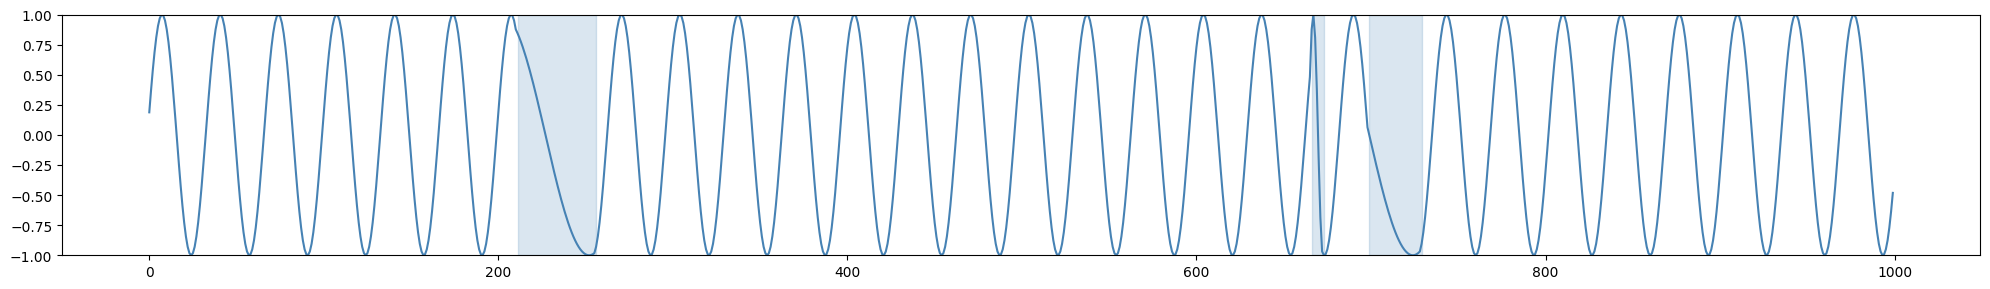

In [7]:
ano_locs, series = eval_dataset[idx]
print(ano_locs.shape, series.shape)
raw_series = series[:,0]

fig = plot_series_and_predictions(
    series=series, 
    gt_anomaly_intervals=ano_locs,
    gt_ylim = (series.min(), series.max()),
    anomalies=None, #results
)
print(ano_locs[0])

### Load Model

In [8]:
test_samples = len(eval_dataset)
model = AnoAgent(data_name=data_name, llm_model=llm_name, max_ts_len=max_ts_len, index_type=index_type, min_acf_period=24, value_scale=10)

In [9]:
pred_vector, sample_request, sample_response = model.sample_get_prompt_and_response(series[:, 0], anomaly_ratio=anomaly_ratio, use_deseasonal=use_deseasonality, use_image=use_image, context=None)

2025-05-18 10:48:29.970 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


In [10]:
sample_request.keys(), sample_request['messages'][0].keys(), sample_response

(dict_keys(['messages', 'temperature', 'stop']),
 dict_keys(['role', 'content']),
 '```json\n[{"start": 666, "end": 685}]\n```')

In [13]:
print(sample_request['messages'][0]['content'][0]['text'][-400:])

 -0.14)
</history>

Assume there are up to 5 anomalies.

Detect ranges of anomalies in this time series, considering the plotted image.
The index of the time series starts from 0 to 1000. 
List one by one, in JSON format. 
If there are no anomalies, answer with an empty list []. Do not say anything other than the answer.
Output template:
[{"start": ..., "end": ...}, {"start": ..., "end": ...}...]



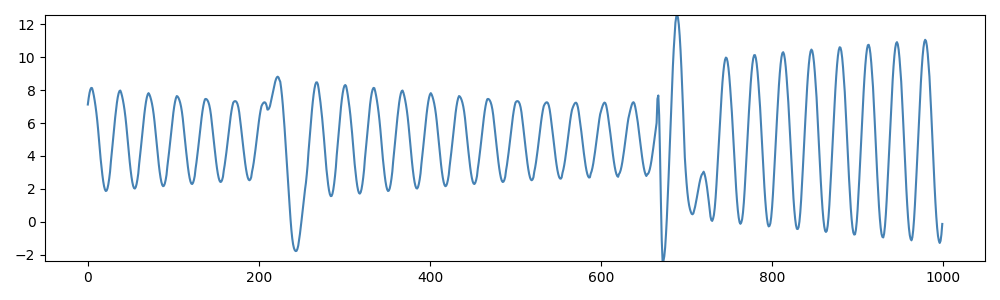

In [14]:
if use_image:
    base64_str = sample_request['messages'][0]['content'][1]['image_url']['url'].split(',')[1]
    img_data = base64.b64decode(base64_str)
    img = Image.open(BytesIO(img_data))
    img.show()

In [15]:
pred_vector = pred_vector.reshape(-1, 1)
pred_vector.shape

(1000, 1)

In [16]:
gt = interval_to_vector(ano_locs.numpy()[0], end=pred_vector.shape[0])
our_metrics = compute_metrics(gt, pred_vector.astype(bool).astype(int))
our_metrics

{'precision': 0.368,
 'recall': 0.085,
 'f1': 0.139,
 'affi precision': 0.947,
 'affi recall': 0.333,
 'affi f1': 0.493}

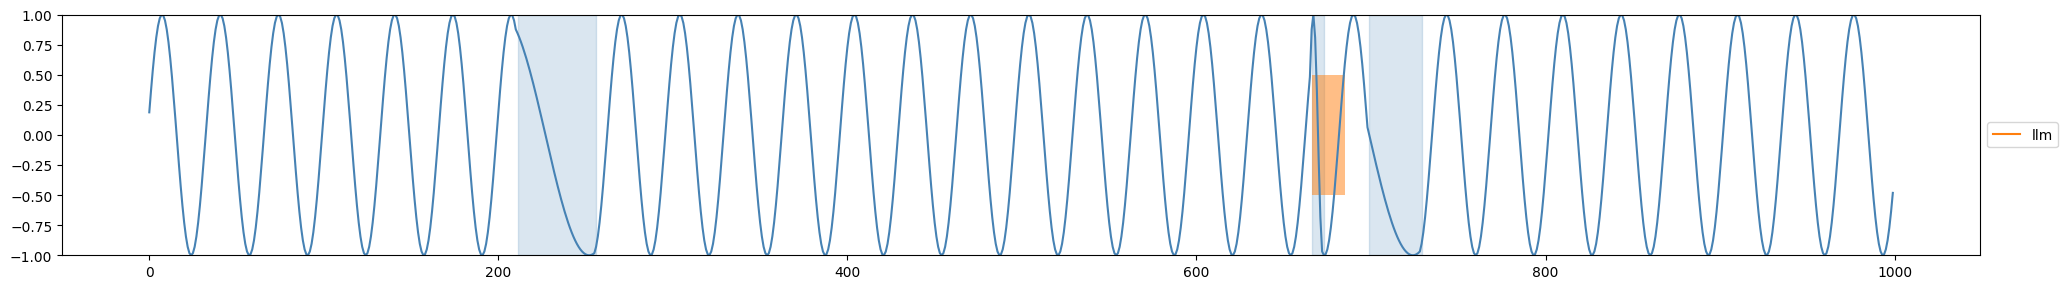

In [17]:
pred_loc = {'llm': pred_vector} 
fig = plot_series_and_predictions(
    series=series, 
    gt_anomaly_intervals=ano_locs,
    gt_ylim = (series.min(), series.max()),
    anomalies=pred_loc,
)

In [15]:
raise Exception()

Exception: 

### For all data

In [18]:
jsonl_filename = f"./results/{data_name}_{llm_name.split('/')[-1]}_itype-{index_type}_ar{int(anomaly_ratio*1000)}_maxlen{max_ts_len}_ts{test_samples}_image{use_image}_ds{use_deseasonality}.jsonl"
if os.path.exists(jsonl_filename):
    with open(jsonl_filename, "w", encoding="utf-8") as f:
        f.write("")
print(jsonl_filename)

./results/freq_gpt-4o_itype-number_ar5_maxlen2000_ts400_imageTrue_dsTrue.jsonl


In [20]:
all_metrics = []
for i, (ano_locs, series) in enumerate(eval_dataset):
    # if i < 329:
    #     continue
    st_time = time.time()
    pred_vector = model.inference(series[:, 0], anomaly_ratio=anomaly_ratio, use_deseasonal=use_deseasonality, use_image=use_image, context=None)
    pred_vector = pred_vector.reshape(-1, 1)
    inference_time = time.time() - st_time
    
    gt = interval_to_vector(ano_locs.numpy()[0], end=pred_vector.shape[0])
    our_metrics = compute_metrics(gt, pred_vector.astype(bool).astype(int))
    if i % 10 == 0:
        print(i, our_metrics)
    all_metrics.append(our_metrics)
    
    result_entry = {
        "eval_idx": i,
        "pred": pred_vector.reshape(-1).tolist(),
        "metric": our_metrics,
        "inference_time": inference_time,
    }
    
    with open(jsonl_filename, "a", encoding="utf-8") as jsonl_file:
        jsonl_file.write(json.dumps(result_entry, ensure_ascii=False) + "\n")

2025-05-18 10:50:47.936 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:50:48.862 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


0 {'precision': 0.368, 'recall': 0.085, 'f1': 0.139, 'affi precision': 0.947, 'affi recall': 0.333, 'affi f1': 0.493}


2025-05-18 10:50:54.157 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:50:55.053 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:50:57.920 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:50:58.993 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:00.309 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:02.887 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:05.227 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:06.359 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:08.085 

10 {'precision': 1.0, 'recall': 0.778, 'f1': 0.875, 'affi precision': 1.0, 'affi recall': 1.0, 'affi f1': 1.0}


2025-05-18 10:51:11.266 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:12.874 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1
2025-05-18 10:51:15.214 | DEBUG    | openai_api:openai_client:31 - API key: ****jOgA, endpoint: https://api.openai.com/v1


KeyboardInterrupt: 

In [21]:
aaa = glob.glob('./results/*')
aaa

['./results/freq_gpt-4o_itype-number_ar5_maxlen2000_ts400_imageTrue_dsTrue.jsonl']

In [22]:
all_results = []
for path in aaa:
    print(path)
    result_df = pd.read_json(path, lines=True)
    aa =  average_dict_values(result_df['metric'].tolist())
    log_str = []
    for k, v in aa.items():
    #     print(v)
        log_str.append(f'{v*100:.2f}')
    print('\t'.join(log_str))
    all_results.append(aa)
    
# all_results

./results/freq_gpt-4o_itype-number_ar5_maxlen2000_ts400_imageTrue_dsTrue.jsonl
49.49	31.76	31.85	79.82	58.21	65.14


In [23]:
aa = average_dict_values(all_results)
log_str = []
for k, v in aa.items():
#     print(v)
    log_str.append(f'{v*100:.2f}')
print('\t'.join(log_str))

49.49	31.76	31.85	79.82	58.21	65.14
